In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Ekstra Ting


| Operation            |          |                                                                    | flops  |
| -------------------- | -------- | ------------------------------------------------------------------ | ------ |
| vektorsum            | $u + v$  | $u,v \in \mathbb{R}^{n}$                                           | $n$    |
| skalar-vektorprodukt | $sv$     | $s \in \mathbb{R}, v \in \mathbb{R}^{n}$                           | $n$    |
| række-søjleprodukt   | $u^{T}v$ | $u^{T} \in \mathbb{R}^{1 \times n}, v \in \mathbb{R}^{n \times 1}$ | $2n$   |
| ydre produkt         | $vw^{T}$ | $v \in \mathbb{R}^{m \times 1}, w^{T} \in \mathbb{R}^{1 \times n}$ | $mn$   |
| matrixsum            | $A + B$  | $A,B \in \mathbb{R}^{m \times n}$                                  | $mn$   |
| skalar-matrixprodukt | $sA$     | $s \in \mathbb{R}, A \in \mathbb{R}^{m \times n}$                  | $mn$   |
| matrix-vektorprodukt | $Av$     | $A \in \mathbb{R}^{m \times n}, v \in \mathbb{R}^{n \times 1}$     | $2mn$  |
| matrixprodukt        | $AB$     | $A \in \mathbb{R}^{m \times n}, B \in \mathbb{R}^{n \times r}$     | $2mnr$ |

Tabel 5.1: Omkostninger ved vektor- og matrixberegninger

Løsning af andengradsligning:
$$
x = \frac{-b \pm \sqrt{b^{2} - 4ac}}{2a}
$$

In [2]:
# Funktion defineret ud fra matrixprodukt omkostning fra tabel 5.1 i notesættet
def product_flops(M1,M2):
    S1 = M1.shape
    S2 = M2.shape
    return S1[0] * S2[1] * 2 * S2[0]

In [3]:
# Funktion defineret ud fra matrixsum omkostning fra tabel 5.1 i notesættet
def sum_flops(M1, M2):
    S1 = M1.shape
    return S1[0] * S1[1]

In [4]:
# Rækkeoperationer fra tabel 6.1
a = np.ones((3,3))

a[[0,1], :] = a[[1,0], :]   # R0 <-> R1
a[0, :] *= 2                # R0 -> 2 R0
a[0, :] += 2 * a[1, :]      # R0 -> R0 + 2 R1

In [5]:
# Selvlavet funktion, som får matricer ned på reduceret echelonform
def reduce_echelon(A, last_col = True):
    # finder dimensioner
    rows, cols = A.shape

    # hvis b er en del af matricen og man ikke vil reducere sidste søjle
    if not last_col:
        cols -= 1

    # holder styr på søjlen til senere
    cur_col = 0

    # reducerer for hver række
    for i in range(rows):

        # hvis der er flere rækker end søjler skipper man de sidste (nulrækker)
        if cur_col >= cols:
            return A
        
        # hvis nuværende søjle har 0 som element skal rækken byttes
        while A[i, cur_col] == 0:

            # finder en række uden 0 til at bytte med
            for j in range(i+1, rows):
                if A[j, cur_col] != 0:
                    A[[i,j], :] = A[[j,i], :]
                    break

            # hvis ingen passer er der ingen pivotelement i søjlen så næste søjle vælges
            # (while løkken kan fortsætte efter der plusses)
            cur_col += 1

            # hvis cur_col overstiger cols i while løkken skal den stadig stoppe
            if cur_col >= cols:
                return A

        # hvis første element i søjlen ikke er 0 kan rækkeoperationer endelig laves
        if A[i, cur_col] != 0:
            A[i] /= A[i, cur_col]   # deler rækken med pivotelementet så den bliver 1
            for j in range(i+1, rows):
                A[j] -= A[j,cur_col] * A[i] # trække række fra andre rækker så de bliver 0 i søjlen
        
        # søjlen bliver ikke incremented automatisk
        cur_col += 1
    return A

In [6]:
lign = np.random.rand(4,4)
# lign = np.array([[1,1,2,1,0],
#                  [1,1,3,2,1],
#                  [2,2,5,4,1]],dtype=float)
print(lign)
print(reduce_echelon(lign, last_col=False))

[[0.15126963 0.87472022 0.30416965 0.77522737]
 [0.45766082 0.10067824 0.07818584 0.27524905]
 [0.92266591 0.51478036 0.89340874 0.54584937]
 [0.23508833 0.521562   0.56355705 0.99918216]]
[[ 1.          5.78252376  2.01077805  5.12480515]
 [-0.          1.          0.33077341  0.81318603]
 [ 0.          0.          1.         -0.41512078]
 [ 0.          0.          0.          0.62847871]]


In [7]:
machine_epsilon = np.finfo(float).eps

In [8]:
# Fra afsnit 15.3 i notesættet
def forbedret_gram_schmidt(a):
    _, k = a.shape
    q = np.copy(a)
    r = np.zeros((k, k))
    for i in range(k):
        r[i, i] = np.linalg.norm(q[:, i])
        q[:, i] /= r[i, i]
        r[[i], i+1:] = q[:, [i]].T @ q[:, i+1:]
        q[:, i+1:] -= q[:, [i]] @ r[[i], i+1:]
    return q, r

# Lavet ud fra afsnit 26.1 i notesættet
def FørsteQRMetode(A):
    A0 = np.copy(A)
    for k in range(50):
        Q,R = forbedret_gram_schmidt(A0)
        A0 = R@Q
    return A0

# Andrews Funktioner

In [9]:
# Fra eksempel 9.18 i notesættet
def house_transformation(s, v, w):
    return w - s * v @ (v.T @ w)

In [10]:
# Fra afsnit 10.3.2 i notesættet
def svdapprox(u, s, vt, r):
    "Givet svd u, s, vt angiv forkortelsen til niveau r."
    return u[:, :r] @ np.diag(s[:r]) @ vt[:r, :]

In [11]:
# Fra afsnit 13.3 i notesættet
def trapz(f, h):
    return h * (f[0] + 2*np.sum(f[1:-1]) + f[-1]) / 2

def indre_produkt(f, g, h):
    return trapz(f * g, h)

def norm_sq(f, h):
    return indre_produkt(f, f, h)

In [12]:
# Fra eksempel 14.1 i notesættet
def proj_på(v, u):
    return np.vdot(v, u) / np.vdot(v, v) * v

In [13]:
# Fra afsnit 15.3 i notesættet
def klassisk_gram_schmidt(a):
    _, k = a.shape
    q = np.empty_like(a)
    r = np.zeros((k, k))
    for j in range(k):
        r[:j, [j]] = q[:, :j].T @ a[:, [j]]
        w = a[:, [j]] - q[:, :j] @ r[:j, [j]]
        r[j, j] = np.linalg.norm(w)
        q[:, [j]] = w / r[j, j]
    return q, r

In [14]:
# Fra afsnit 15.3 i notesættet
def forbedret_gram_schmidt(a):
    _, k = a.shape
    q = np.copy(a)
    r = np.zeros((k, k))
    for i in range(k):
        r[i, i] = np.linalg.norm(q[:, i])
        q[:, i] /= r[i, i]
        r[[i], i+1:] = q[:, [i]].T @ q[:, i+1:]
        q[:, i+1:] -= q[:, [i]] @ r[[i], i+1:]
    return q, r

In [15]:
# Fra afsnit 16.4 i notesættet
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

In [16]:
# Fra afsnit 17.3 i notesættet
def house(x):
    u = x / np.linalg.norm(x)
    eps = +1 if u[0, 0] >= 0 else -1
    s = 1 + np.abs(u[0, 0])
    v = (eps / s) * u
    v[0, 0] = 1
    return v, s

def householder_qr_data(a):
    data = np.copy(a)
    _, k = a.shape
    s = np.empty(k)
    for j in range(k):
        v, s[j] = house(data[j:, [j]])
        data[j:, j:] -= (s[j] * v) @ (v.T @ data[j:, j:])
        data[j+1:, [j]] = v[1:]
    return data, s

def householder_qr(a):
    data, s = householder_qr_data(a)
    n, k = a.shape
    r = np.triu(data[:k, :k])
    q = np.eye(n, k)
    for j in reversed(range(k)):
        x = data[j+1:, [j]]
        v = np.vstack([[1], x])
        q[j:, j:] -= (s[j] * v) @ (v.T @ q[j:, j:])
    return q, r

# Fra afsnit 17.4 i notesættet
def householder_lsq(a, b):
    data, s = householder_qr_data(a)
    _, k = a.shape
    r = np.triu(data[:k, :k])
    c = np.copy(b)
    for j in range(k):
        x = data[j+1:, [j]]
        v = np.vstack([[1], x])
        c[j:] -= (s[j] * np.vdot(v, c[j:])) * v
    return back_subs(r, c[:k])

Text(0, 0.5, '$y_{1}$')

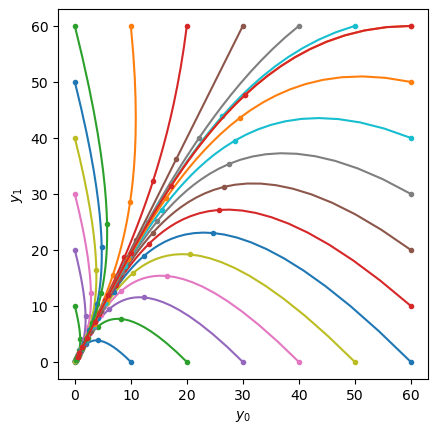

In [17]:
# Fra eksempel 22.4 i notesættet
def sol(r0, r1, v, lambda0, lambda1, t):
    c = np.linalg.solve(v, np.array([r0, r1])[:, np.newaxis])
    return (c[0] * v[:, [0]] * np.exp(lambda0 * t) 
            + c[1] * v[:, [1]] * np.exp(lambda1 * t))


# Funktionen bruges til at plotte løsninger til differentialligninger med flere startværdier såsom sådan her:
t = np.linspace(0, 100, 100)
v0 = np.array([1.0, 2.0])[:, np.newaxis]
v1 = np.array([1.0, -2.0])[:, np.newaxis]
lambda0 = -1.0 / 20.0
lambda1 = -3.0 / 20.0
v = np.hstack([v0, v1])

marks = dict(marker='o', markevery=10, markersize=3)
fig, ax = plt.subplots()
ax.set_aspect('equal')
for s in np.linspace(10, 60, 6):
    ax.plot(*sol(s, 0, v, lambda0, lambda1, t), **marks)
    ax.plot(*sol(s, 60, v, lambda0, lambda1, t), **marks)
for s in np.linspace(10, 60, 6):
    ax.plot(*sol(0, s, v, lambda0, lambda1, t), **marks)
    ax.plot(*sol(60, s, v, lambda0, lambda1, t), **marks)
ax.set_xlabel('$y_{0}$')
ax.set_ylabel('$y_{1}$')

In [18]:
# Fra eksempel 22.5 i notesættet
def sol_c(r0, r1, v_c, lambda_c, t):
    w = v_c.real
    z = v_c.imag
    v = np.hstack([w, z])
    a = lambda_c.real
    b = lambda_c.imag
    r = np.array([r0, r1])[:, np.newaxis]
    c = np.linalg.solve(v, r)
    return (c[0] * np.exp(a*t) * (np.cos(b*t) 
            * w - np.sin(b*t) * z) 
            + c[1] * np.exp(a*t) 
            * (np.sin(b*t) * w + np.cos(b*t) * z))

# bruges til det samme, men med komplekse egenværdier

In [19]:
# Fra eksempel 24.1 i notesættet
def potens_skridt(a, w):
    v = a @ w
    v /= np.linalg.norm(v)
    lambda_ny = np.vdot(v, a @ v)
    return lambda_ny, v

In [20]:
# Fra eksempel 24.8 i notesættet
def sing_skridt_del(a, v):
    w = a @ v
    sigma = np.linalg.norm(w)
    u = w / sigma
    return sigma, u

In [21]:
# Fra afsnit 16.4 i notesættet
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

# Fra eksempel 24.10 i notesættet 
# mu er ændret til a for at få matricen som input
def inv_potens_skridt(q, r, w, a):
    v = back_subs(r, q.T @ w)
    v /= np.linalg.norm(v)
    lambda_ny = np.vdot(v, a @ v)
    return lambda_ny, v

In [22]:
# Fra afsnit 16.4 i notesættet
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

# Fra eksempel 24.13 i notesættet
def rayleigh_skridt(a, lambda_est, w):
    m, _ = a.shape
    b = a - lambda_est * np.eye(m)
    q, r = householder_qr(b)
    v = back_subs(r, q.T @ w)
    v /= np.linalg.norm(v)
    lambda_ny = np.vdot(v, a @ v)
    return lambda_ny, v

In [23]:
# Fra eksempel 25.1 i notesættet
def house(x):
    norm_x = np.linalg.norm(x)
    if norm_x == 0:
        v = np.zeros_like(x)
        v[0, 0] = 1
        s = 0
    else:
        u = x / norm_x
        eps = +1 if u[0, 0] >= 0 else -1
        s = 1 + np.abs(u[0, 0])
        v = (eps / s) * u
        v[0, 0] = 1
    return v, s

# Fra afsnit 25.1 i notesættet
def hessenberg_data(a):
    data = np.copy(a)
    n, _ = a.shape
    s = np.empty(n-2)
    for j in range(n-2):
        v, s[j] = house(data[j+1:, [j]])
        data[j+1:, j:] -= (s[j] * v) @ (v.T @ data[j+1:, j:])
        data[:, j+1:] -= (s[j] * (data[:, j+1:] @ v)) @ v.T
        data[j+2:, [j]] = v[1:]
    return data, s

def hessenberg(a):
    data, s = hessenberg_data(a)
    return np.triu(data, -1)

def hessenberg_qh(a):
    data, s = hessenberg_data(a)
    n, _ = a.shape
    h = np.triu(data, -1)
    q = np.eye(n)
    for j in reversed(range(n-2)):
        x = data[j+2:, [j]]
        v = np.vstack([[1], x])
        q[j+1:, j+1:] -= (s[j] * v) @ (v.T @ q[j+1:, j+1:])
    return q, h

In [24]:
# Fra afsnit 25.2 i notesættet
def house_plus(x):
    norm_x = np.linalg.norm(x)
    if norm_x == 0:
        v = np.zeros_like(x)
        v[0, 0] = 1
        s = 0
        eps = 1
    else:
        u = x / norm_x
        eps = +1 if u[0, 0] >= 0 else -1
        s = 1 + np.abs(u[0, 0])
        v = (eps / s) * u
        v[0, 0] = 1
    return v, s, eps, norm_x

def tridiagonal_data(a):
    data = np.copy(a)
    if not np.allclose(a, a.T):
        raise np.linalg.LinAlgError(
        'In tridiagonal_data() input must '+
        'be a symmetric matrix')
    n, _ = a.shape
    s = np.empty(n - 2)
    for j in range(n - 2):
        v, s[j], eps, norm = house_plus(data[j+1:, [j]])
        u = s[j] * (data[j+1:, j+1:] @ v)
        w = u - ((s[j]/2) * (u.T @ v)) * v
        v_wT = v @ w.T
        data[j+1, j] = - eps * norm
        data[j, j+1] = data[j+1, j]
        data[j+1:, j+1:] -= v_wT + v_wT.T
        data[j+2:, [j]] = v[1:]
    return data, s

def tridiagonal_qt(a):
    data, s = tridiagonal_data(a)
    n, _ = a.shape
    t = np.tril(np.triu(data, -1), 1)
    q = np.eye(n)
    for j in reversed(range(n-2)):
        x = data[j+2:, [j]]
        v = np.vstack([[1], x])
        q[j+1:, j+1:] -= (s[j] * v) @ (v.T @ q[j+1:, j+1:])
    return q, t

In [25]:
# Fra afsnit 25.3 i notesættet
def house(x):
    norm_x = np.linalg.norm(x)
    if norm_x == 0:
        v = np.zeros_like(x)
        v[0, 0] = 1
        s = 0
    else:
        u = x / norm_x
        eps = +1 if u[0, 0] >= 0 else -1
        s = 1 + np.abs(u[0, 0])
        v = (eps / s) * u
        v[0, 0] = 1
    return v, s

def bidiagonal_data(a):
    data = np.copy(a)
    m, n = a.shape
    kv = n if m > n else m-1
    kh = m if m < n-1 else n-2
    sv = np.zeros(kv)
    sh = np.zeros(kh)
    for k in range(np.max([kv, kh])):
        if k < kv:
            v, sv[k] = house(data[k:, [k]])
            data[k:, k:] -= ((sv[k] * v)
                             @ (v.T @ data[k:, k:]))
            data[k+1:, [k]] = v[1:]
        if k < kh:
            v, sh[k] = house(data[[k], k+1:].T)
            data[k:, k+1:] -= (sh[k] * (data[k:, k+1:]
                                        @ v)) @ v.T
            data[[k], k+2:] = v[1:].T
    return data, sv, sh

def bidiagonal(a):
    data, sv, sh = bidiagonal_data(a)
    return np.tril(np.triu(data), 1)

def bidiagonal_qbpt(a):
    data, sv, sh = bidiagonal_data(a)
    m, n = a.shape
    kv = n if m > n else m-1
    kh = m if m < n-1 else n-2
    b = np.tril(np.triu(data), 1)
    q = np.eye(m)
    pt = np.eye(n)
    for k in reversed(range(np.max([kv, kh]))):
        if k < kh:
            x = data[[k], k+2:]
            vt = np.hstack([[[1]], x])
            pt[k+1:, k+1:] -= (sh[k] * (pt[k+1:, k+1:]
                                        @ vt.T)) @ vt
        if k < kv:
            x = data[k+1:, [k]]
            v = np.vstack([[1], x])
            q[k:, k:] -= (sv[k] * v) @ (v.T @ q[k:, k:])
    return q, b, pt

In [26]:
# Fra afsnit 26.5 i notesættet
def forskudt_qr_trin(a, mu):
    mu_eye = mu * np.eye(*(a.shape))
    q, r = householder_qr(a - mu_eye)
    return r @ q + mu_eye

machine_epsilon = np.finfo(float).eps

def færdig(u):
    return np.allclose(u, np.zeros_like(u),
                       atol = machine_epsilon)

def semi_praktisk_qr_metode(a):
    i_max = 40
    q, t = tridiagonal_qt(a)
    for i in range(i_max):
        mu = t[-1,-1]
        t = forskudt_qr_trin(t, mu)
        if færdig(np.diag(t,-1)):
            break
    return t, i+1

In [27]:
# Fra afsnit 26.5 i notesættet
def wilkinson_forskydning(x):
    a, b, c = x[np.triu_indices_from(x)]
    delta = (a - c) / 2
    eps = 1 if delta >=0 else -1
    nævner = np.abs(delta) + np.sqrt(delta**2 + b**2)
    return c - eps * b**2 / nævner

def færdig_eller(u):
    z = np.argwhere(u < machine_epsilon)[:,0]
    færdig = (z.shape == u.shape)
    delings_indeks = -1
    if z.shape != (0,):
        delings_indeks = z[0] + 1
    return færdig, delings_indeks

def praktisk_qr_metode(a):
    trin = 0
    if a.shape == (1,1):
        return a, trin
    q, t = tridiagonal_qt(a)
    for i in range(20):
        trin += 1
        mu = wilkinson_forskydning(t[-2:,-2:])
        t = forskudt_qr_trin(t, mu)
        færdig, r = færdig_eller(np.abs(np.diag(t, -1)))
        if færdig:
            break
        if r > 0:
            t[:r, :r], j = praktisk_qr_metode(t[:r, :r])
            t[r:, r:], k = praktisk_qr_metode(t[r:, r:])
            trin += j + k
            break
    return t, trin

# Sympy Funktioner

In [28]:
# Integraler (fra aflevering 6)

x = sp.symbols('x')
n, m = sp.symbols('n m', integer=True, positive=True)

sp.integrate(sp.sin(n*x) * sp.sin(m*x), (x, 0, sp.pi))

Piecewise((0, Ne(m, n)), (pi/2, True))

In [29]:
# Differentiering for at finde gradient (fra TØ uge 8)

a = 2.0
b = 2.0
c = -1.0
A, B, C = sp.symbols('A B C')

diff_a = sp.diff((-b + sp.sqrt(b**2 - 4 * A * c)) / (2 * A), A)
grad_a = diff_a.subs(sp.Symbol("A"), a)
diff_b = sp.diff((-B + sp.sqrt(B**2 - 4 * a * c)) / (2 * a), B)
grad_b = diff_b.subs(sp.Symbol("B"), b)
diff_c = sp.diff((-B + sp.sqrt(b**2 - 4 * a * C)) / (2 * a), C)
grad_c = diff_c.subs(sp.Symbol("C"), c)

grad_a, grad_b, grad_c

(-0.0386751345948129, -0.105662432702594, -0.288675134594813)

In [30]:
# L'Hôpital - kan godt tage lang tid at køre, max ~1 min (fra aflevering 9)

t = sp.symbols('t')

y_0 = 2.57 * sp.exp(-0.51 * t) + 87.43 * sp.exp(-0.088 * t)
y_1 = 2.57 * (-2.41) * sp.exp(-0.51 * t) + 87.43 * 0.41 * sp.exp(-0.088 * t)
lhopital = y_1/y_0
sp.limit(lhopital, t, sp.oo)

41/100

In [31]:
# Simplificering af udtryk til polynomium (fra eksamenssæt forår 2020)
# må gerne bruges selvom python ikke må bruges
lam = sp.symbols("lambda")

polynomium = sp.expand((2 - lam) * (3 - lam)**2 - 6 + 2 * lam)
polynomium

-lambda**3 + 8*lambda**2 - 19*lambda + 12

# Matplotlib Funktioner

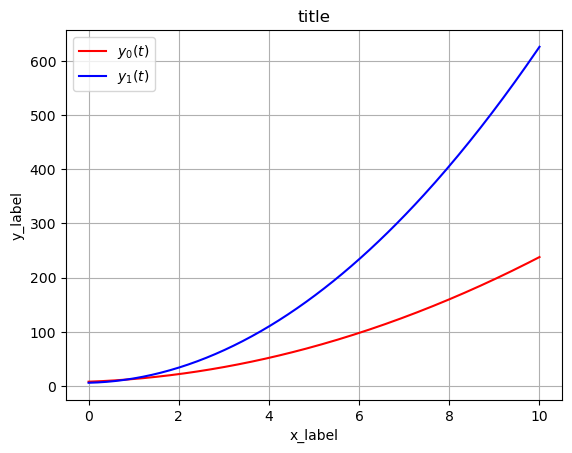

In [32]:
# Plot simpel funktionsudtryk med lables n stuff
x = np.linspace(0, 10, 200)

y1 = 2 * x**2 + 3 * x + 8
y2 = 6 * x**2 + 2 * x + 6

fig, ax = plt.subplots()
ax.plot(x, y1, 'r', label='$y_{0}(t)$') # matplotlib supporter markdown/latex syntaks
ax.plot(x, y2, 'b', label='$y_{1}(t)$')
ax.set_xlabel('x_label')
ax.set_ylabel('y_label')
ax.set_title('title')
ax.legend()
ax.grid()

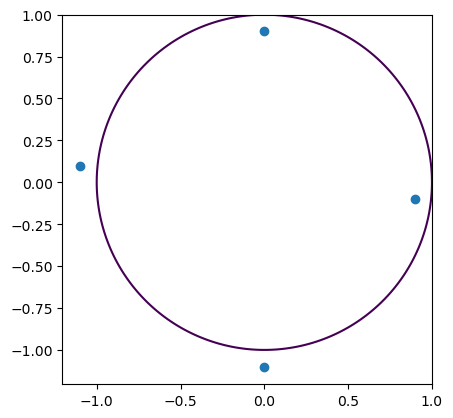

In [33]:
# plot data med cirkel med ligning på formen ax + by + c = x^2 + y^2

x_data = np.array([-1.1, 0, 0.9, 0])[:, np.newaxis]
y_data = np.array([0.1, 0.9, -0.1, -1.1])[:, np.newaxis]

x = np.linspace(-1.0, 1.0, 100)
y = np.linspace(-1.0, 1.0, 100)

X, Y = np.meshgrid(x,y)

# omskrevet til x^2 + y^2 - (ax + by + c) = 0
F = X**2 + Y**2 - 1

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(x_data, y_data, 'o')
ax.contour(X, Y, F, [0])

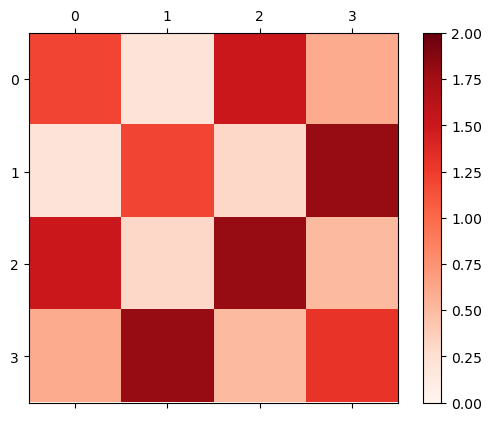

In [34]:
# Plot heatmap med colorbar (man kan også bruge andrews fancy funktion forneden)
A = np.array([[1.2, 0.2, 1.5, 0.6],
              [0.2, 1.2, 0.3, 1.8],
              [1.5, 0.3, 1.8, 0.5],
              [0.6, 1.8, 0.5, 1.3]])

fig, ax = plt.subplots()
im = ax.matshow(A, cmap='Reds', clim=(0.0, 2.0))
fig.colorbar(im)

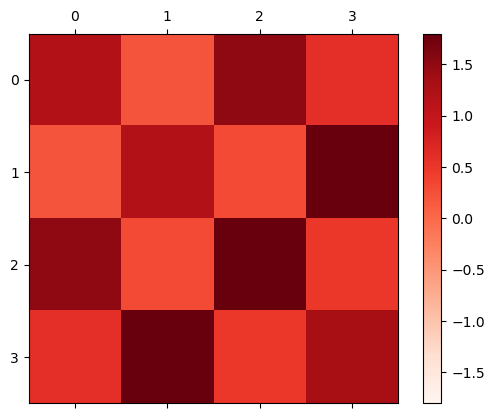

In [35]:
# Fra afsnit 26.4 i notesættet
machine_epsilon = np.finfo(float).eps

def heat_map(a):
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    r = np.max(np.abs(a))
    if r < 20 * machine_epsilon:
        r = 1
    im = ax.matshow(a, cmap='Reds', clim = (-r, r))
    fig.colorbar(im)

heat_map(A)

## Matplotlib Color Table

In [36]:
import math

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle


def plot_colortable(colors, *, ncols=4, sort_colors=True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    # Sort colors by hue, saturation, value and name.
    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        names = list(colors)

    n = len(names)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin/width, margin/height,
                        (width-margin)/width, (height-margin)/height)
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(xy=(swatch_start_x, y-9), width=swatch_width,
                      height=18, facecolor=colors[name], edgecolor='0.7')
        )

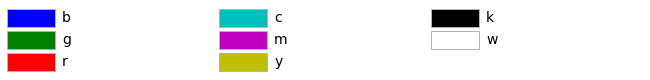

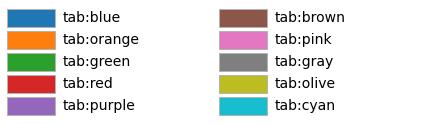

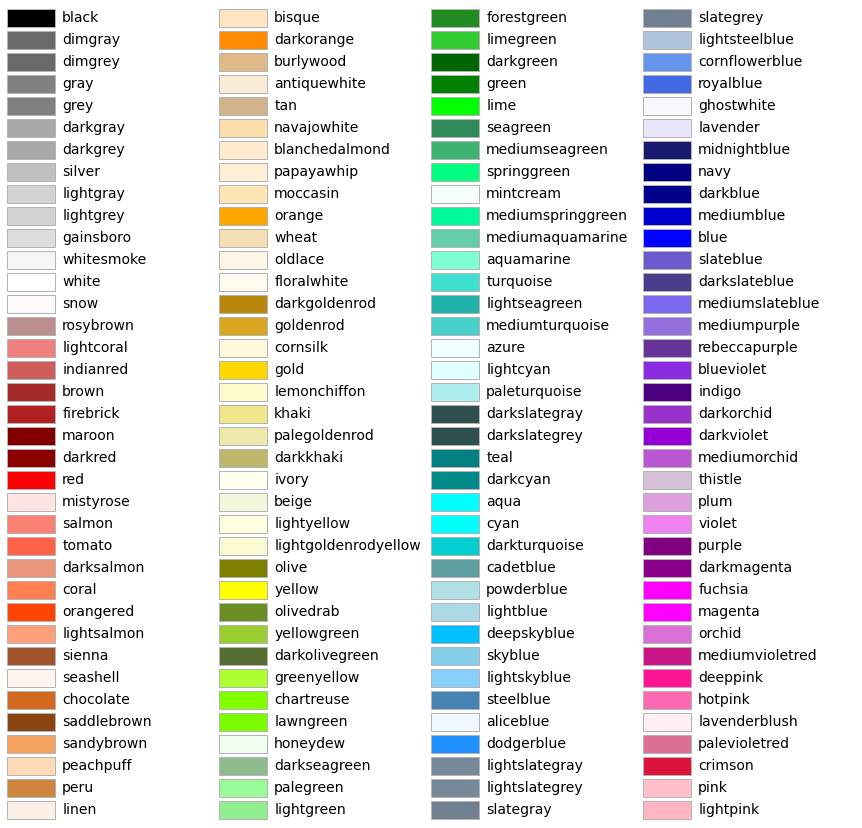

In [37]:
plot_colortable(mcolors.BASE_COLORS, ncols=3, sort_colors=False)

plot_colortable(mcolors.TABLEAU_COLORS, ncols=2, sort_colors=False)

plot_colortable(mcolors.CSS4_COLORS)

## Matplotlib Colormaps

In [38]:
from colorspacious import cspace_converter

import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl

cmaps = {}

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))


def plot_color_gradients(category, cmap_list):
    # Create figure and adjust figure height to number of colormaps
    nrows = len(cmap_list)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh,
                        left=0.2, right=0.99)
    axs[0].set_title(f'{category} colormaps', fontsize=14)

    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect='auto', cmap=mpl.colormaps[name])
        ax.text(-0.01, 0.5, name, va='center', ha='right', fontsize=10,
                transform=ax.transAxes)

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs:
        ax.set_axis_off()

    # Save colormap list for later.
    cmaps[category] = cmap_list

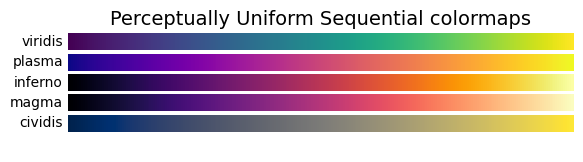

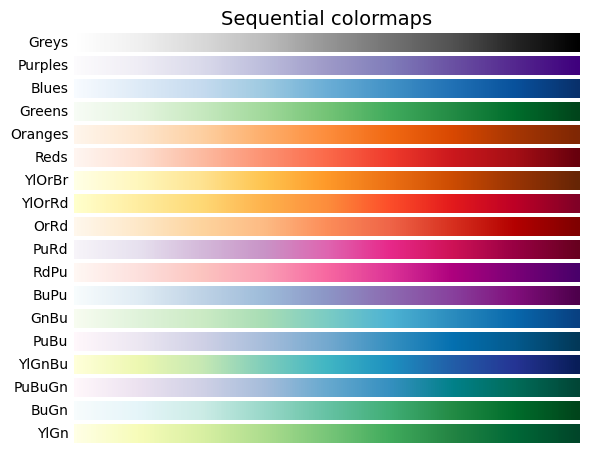

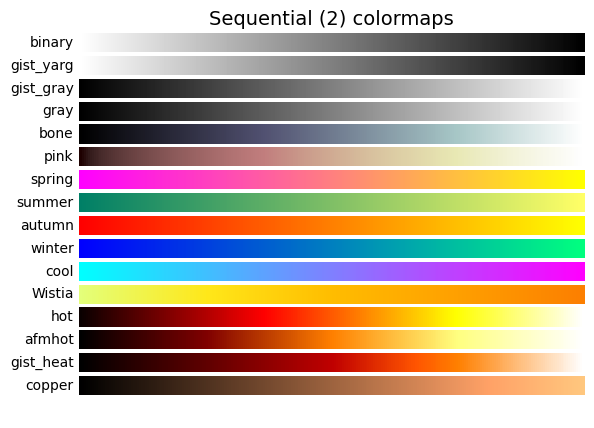

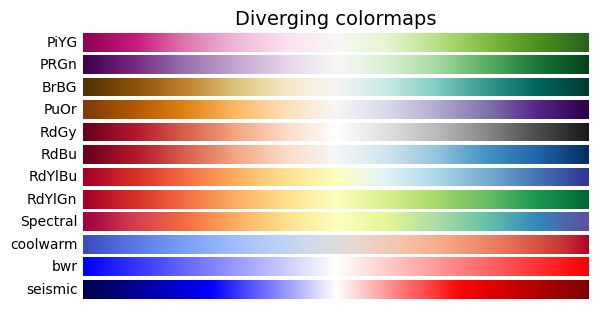

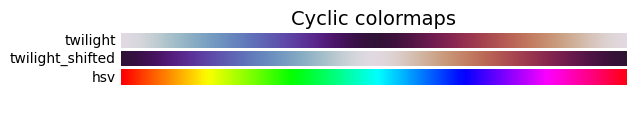

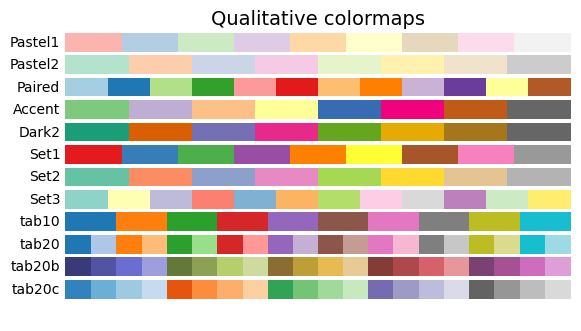

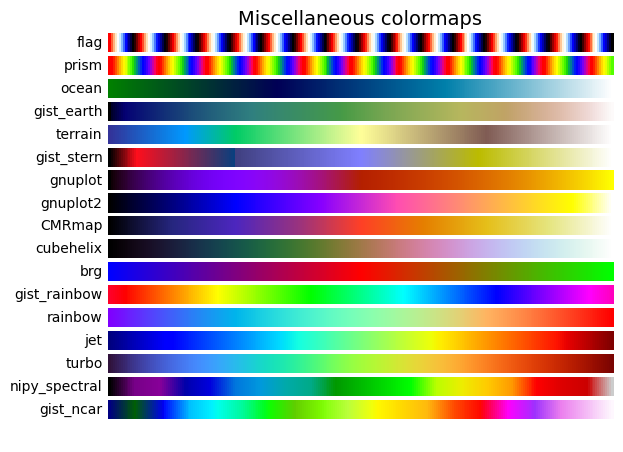

In [39]:
plot_color_gradients('Perceptually Uniform Sequential',
                     ['viridis', 'plasma', 'inferno', 'magma', 'cividis'])

plot_color_gradients('Sequential',
                     ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
                      'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
                      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn'])

plot_color_gradients('Sequential (2)',
                     ['binary', 'gist_yarg', 'gist_gray', 'gray', 'bone',
                      'pink', 'spring', 'summer', 'autumn', 'winter', 'cool',
                      'Wistia', 'hot', 'afmhot', 'gist_heat', 'copper'])

plot_color_gradients('Diverging',
                     ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu',
                      'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic'])

plot_color_gradients('Cyclic', ['twilight', 'twilight_shifted', 'hsv'])

plot_color_gradients('Qualitative',
                     ['Pastel1', 'Pastel2', 'Paired', 'Accent', 'Dark2',
                      'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b',
                      'tab20c'])

plot_color_gradients('Miscellaneous',
                     ['flag', 'prism', 'ocean', 'gist_earth', 'terrain',
                      'gist_stern', 'gnuplot', 'gnuplot2', 'CMRmap',
                      'cubehelix', 'brg', 'gist_rainbow', 'rainbow', 'jet',
                      'turbo', 'nipy_spectral', 'gist_ncar'])